# Example: Regime-Aware Sentiment, Replacing EMA Crossover with the Generative Model Posterior

Every Session 2 engine so far has used the same EMA-crossover signal $\lambda_t = -G \cdot (\bar{S}^{\text{short}}_t / \bar{S}^{\text{long}}_t - 1)$, a technical rule that knows nothing about the regime-switching jump model the synthetic path was generated from. But **the generative model itself is a regime detector by construction**: its state posteriors $P(s_t = k \mid \text{obs}_{1:t})$ report, at every trading day, the probability that the current latent state is each of the states the model was fit to, partitioned into bull and bear groups by the sign of each emission mean.

In this example we replace the EMA-crossover $\lambda$ with a **regime-aware $\lambda$** derived from [the `forward_filter(...)` function](https://varnerlab.github.io/JumpHMM.jl/) in three steps:
* __Partition states by emission sign:__ Each state has a Student-t emission with mean $\mu_k$; assign state $k$ to _bear_ if $\mu_k < 0$ and _bull_ if $\mu_k > 0$.
* __Aggregate posteriors into a scalar:__ Sum per-day posteriors over bear states to get $P_{\text{bear}}(t)$, then map to $\lambda_t^{\text{regime}} = 2 \cdot (P_{\text{bear}}(t) - 0.5) \in [-1, +1]$.
* __Drop it into the engine:__ Feed the regime-aware $\lambda$ into the Cobb-Douglas preference-weight formula in place of the EMA-crossover value.

The result closes a narrative loop: Session 1's generative surrogate isn't just a path generator anymore; it's also the engine's sentiment input.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Build a regime-aware sentiment signal from latent-state posteriors:__ Derive a regime-aware sentiment signal from a state-space model's filtered posteriors over latent states. Aggregate the per-state probabilities by the sign of their emission mean to collapse the posterior into a scalar regime score the allocator can consume.
> * __Compare two sentiment inputs on a fixed price path:__ Run the same allocator twice on a fixed price path with two competing sentiment inputs, holding everything else constant. Read the wealth trajectories to judge which signal timed regime shifts better on that path.
> * __Stress-test a sentiment swap across a Monte Carlo scenario:__ Run the regime-aware allocator across a fixed Monte Carlo scenario and compute a paired per-path excess distribution against the baseline signal. Use both the marginal scorecard and the paired excess to separate sample-level differences from systematic edge.

Let's dive in!

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations. See the comments in the code for more details on each constant, its purpose, units, etc.

In [2]:
# Regime-aware replay configuration
B₀ = 10_000.0                # starting budget (USD)
Δt = 1.0 / 252.0             # trading-day step (years)
L_short = 21                 # short EMA window (days)
L_long = 63                  # long EMA window (days)
L_growth = 10                # EMA window for smoothed market growth rate (days)
GAIN = 10.0                  # gain constant G for EMA-λ (dimensionless)
offset = L_short + L_long    # warmup offset before trading begins (days)
T_total = 336                # total path length (days): 84 warmup + 252 active
SCENARIO_SEED = 2026         # RNG seed (matches Example 1 + Example 4)
ALLOCATION_EPSILON = 0.1     # minimum share count for non-preferred assets
TRIGGER_MAX_DRAWDOWN = 0.15  # drawdown trigger threshold (circuit breaker)
TRIGGER_MAX_TURNOVER = 0.50  # max fraction of wealth traded per rebalance
ENGINE_PRIOR_CCGR_PCT = 32.0 # bias-correction anchor (matches Core MC notebook); tunable

32.0

### Implementations
We define four helper functions used throughout this notebook. They collapse the full 50-state generative model posterior into a scalar $\lambda_t^{\text{regime}}$, mimic the engine's per-path backtest loop with that alternative signal, partition generative model states into bull/bear groups, and apply the same bias-correction location shift used by the Core MC notebook so the regime and EMA arms are anchored to a credible long-run CCGR.

> __`bear_state_indices(model::JumpHiddenMarkovModel)`__
>
> Partition the generative model's 50 states into bull and bear groups by the sign of each state's Student-t emission mean $\mu_k$. Returns a `Vector{Int}` of state indices where $\mu_k < 0$ (the _bear_ states).

> __`compute_regime_lambda(model, growth_rates, bear_idx)`__
>
> Run [the `forward_filter(...)` function](https://varnerlab.github.io/JumpHMM.jl/) on a vector of daily growth rates, sum the state posteriors over the bear group to get $P_{\text{bear}}(t)$, and return $\lambda_t^{\text{regime}} = 2(P_{\text{bear}}(t) - 0.5)$ padded to the full series length. Return type is `Vector{Float64}`.

> __`backtest_engine_regime(scenario, tickers, sim_params, market_model, rules_params; ...)`__
>
> Mirror of the library's [the `backtest_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_engine) but with the path-local $\lambda_t^{\text{regime}}$ signal instead of EMA crossover. Iterates each of the `n_paths` paths, computes growth rates, runs `forward_filter`, builds the regime λ, constructs a [`MyRebalancingContextModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.MyRebalancingContextModel), runs [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.run_rebalancing_engine), and collects per-path final wealth, max drawdown, Sharpe ratio, and the full per-path wealth matrix `wealth_paths` into a [`MyBacktestResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestResult). The wealth matrix is required by the bias-correction step in Task 3.

> __`apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr, Δt)`__
>
> Apply a uniform per-step exponential drag to every wealth path so that each path's continuously-compounded growth rate is reduced by `bias_pct_per_yr` per year. Per-path rank order is preserved; the entire distribution is location-shifted in CCGR space. We use it in Task 3 to anchor each daily-rebalanced engine's median synthetic CCGR to `ENGINE_PRIOR_CCGR_PCT`, removing the SIM rebalancing-alpha artifact that inflates raw synthetic medians.

The four helper definitions appear in the code cell below.

In [3]:
# hmm_forward_filter is an alias in eCornellAIFinance for JumpHMM.forward_filter.

"""
    bear_state_indices(model::JumpHiddenMarkovModel) -> Vector{Int}

Return the indices of the HMM states whose emission mean μ is negative.
Used to split the latent state space into "bear" (μ<0) and "bull" (μ≥0)
groups for collapsing the full posterior into a scalar sentiment signal.
"""
function bear_state_indices(model::JumpHiddenMarkovModel)::Vector{Int}
    centers = [e.μ for e ∈ model.emissions];
    return findall(centers .< 0.0);
end

"""
    compute_regime_lambda(model::JumpHiddenMarkovModel,
        growth_rates::Vector{Float64}, bear_idx::Vector{Int};
        pad_to::Int = 0) -> Vector{Float64}

Build the regime-aware λ series from HMM state posteriors.

### Algorithm
1. Call `forward_filter(model, growth_rates)` → posterior matrix
   of shape `(n_obs, n_states)` (rows are time, columns are states).
2. For each time step `t`, sum posterior probabilities over `bear_idx`
   to get `P_bear(t) ∈ [0, 1]`.
3. Map to `λ_regime(t) = 2 * (P_bear(t) - 0.5) ∈ [-1, 1]`.
4. If `pad_to > n_obs`, left-pad with the first λ value so the output
   length matches the caller's full series (the warmup region).

### Returns
- `Vector{Float64}` of length `max(n_obs, pad_to)` with the scalar λ signal.
"""
function compute_regime_lambda(model::JumpHiddenMarkovModel,
    growth_rates::Vector{Float64}, bear_idx::Vector{Int};
    pad_to::Int = 0)::Vector{Float64}

    # hmm_forward_filter returns a (n_obs × n_states) matrix of normalized
    # filtered posteriors: each row sums to 1 and gives P(state_k | obs_{1:t}).
    posteriors = hmm_forward_filter(model, growth_rates);
    n_obs = size(posteriors, 1);
    P_bear = [sum(posteriors[t, k] for k ∈ bear_idx) for t ∈ 1:n_obs];
    λ_reg  = 2.0 .* (P_bear .- 0.5);

    if pad_to > n_obs
        prefix = fill(λ_reg[1], pad_to - n_obs);
        return vcat(prefix, λ_reg);
    else
        return λ_reg;
    end
end

"""
    backtest_engine_regime(scenario, tickers, sim_params, market_model, rules_params;
        B₀, offset, L_growth) -> MyBacktestResult

Like `backtest_engine` but uses the HMM regime-posterior λ instead of the
EMA crossover. Per path: extract the market growth-rate observations, run
`forward_filter`, collapse to a bear-posterior scalar, feed that to the
rebalancing engine, and collect the standard per-path metrics plus the
full `(n_active+1, n_paths)` wealth matrix `wealth_paths`. The wealth
matrix is required by `apply_bias_correction`.
"""
function backtest_engine_regime(scenario::MyBacktestScenario,
    tickers::Vector{String},
    sim_params::Dict{String,Tuple{Float64,Float64,Float64}},
    market_model::JumpHiddenMarkovModel,
    rules_params::NamedTuple;
    B₀::Float64 = 10_000.0, offset::Int = 84,
    L_growth::Int = 10)::MyBacktestResult

    Δt = 1.0 / 252.0;
    n_paths = scenario.n_paths;
    n_steps = scenario.n_steps;
    N = length(tickers);
    n_trading = n_steps - offset;
    bear_idx = bear_state_indices(market_model);

    final_wealth  = zeros(n_paths);
    max_drawdowns = zeros(n_paths);
    sharpe_ratios = zeros(n_paths);
    wealth_paths  = zeros(n_trading + 1, n_paths);

    for p ∈ 1:n_paths

        # --- Step 1: Extract this path's market prices ---
        mkt = scenario.market_paths[p, :];

        # --- Step 2: Recover annualized growth rates ---
        gm_raw = compute_market_growth(mkt; Δt = Δt);

        # --- Step 3: Regime-aware λ from HMM posteriors (padded to full length) ---
        λ_regime = compute_regime_lambda(market_model, gm_raw, bear_idx; pad_to = n_steps);
        λ_regime[1:offset] .= 0.0;   # zero warmup so first-trading-day λ is neutral

        # --- Step 4: Smooth gm for the preference-weight market factor ---
        gm_e = compute_ema(gm_raw; window = L_growth);

        # --- Step 5: Build the engine context and price matrix ---
        pmatrix = zeros(n_steps, N + 1);
        pmatrix[:, 1] = 1:n_steps;
        for k ∈ 1:N
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        ctx = build(MyRebalancingContextModel, (
            B = B₀, tickers = tickers, marketdata = pmatrix,
            marketfactor = gm_e, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = 0.1
        ));

        rules = build(MyTriggerRules, (
            max_drawdown = rules_params.max_drawdown,
            max_turnover = rules_params.max_turnover,
            rebalance_schedule = ones(Int, n_trading)
        ));

        # --- Step 6: Run the engine and collect metrics ---
        results = run_rebalancing_engine(ctx, rules, λ_regime;
            offset = offset, allocator = :cobb_douglas);
        wealth = compute_wealth_series(results, pmatrix, tickers; offset = offset);

        wealth_paths[:, p] .= wealth;
        final_wealth[p] = wealth[end];
        returns = diff(wealth) ./ wealth[1:end-1];
        # Running high-water mark + worst-case drawdown fraction on this path.
        peak    = accumulate(max, wealth);
        max_drawdowns[p] = maximum((peak .- wealth) ./ peak);
        # Annualized volatility (finance convention): std of daily simple returns × √252.
        vol = std(returns) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        sharpe_ratios[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end

    result = MyBacktestResult();
    result.scenario_label = scenario.label;
    result.strategy_label = "Cobb-Douglas Engine (regime-λ)";
    result.final_wealth   = final_wealth;
    result.max_drawdowns  = max_drawdowns;
    result.sharpe_ratios  = sharpe_ratios;
    result.wealth_paths   = wealth_paths;
    return result;
end;

"""
    apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr, Δt) -> MyBacktestResult

Apply a uniform per-step exponential drag to every wealth path so that each
path's continuously-compounded growth rate is reduced by `bias_pct_per_yr` /
year. The correction is

    W_corr[p, t] = W[p, t] · exp(-bias · (t-1) · Δt),

where `bias = bias_pct_per_yr / 100`. Per-path rank order is preserved
(rank correlation = 1 with the input); the entire distribution is location-
shifted in CCGR space. Used in Task 3 to anchor each daily-rebalanced
engine's median synthetic CCGR to `ENGINE_PRIOR_CCGR_PCT` so the synthetic
ensemble characterizes percentile and tail structure around a credible
central tendency rather than a SIM-inflated point. Mirrors the helper of
the same name in the Core Monte-Carlo evaluation notebook.
"""
function apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr::Float64,
        Δt::Float64)::MyBacktestResult
    n_t, n_p = size(r.wealth_paths);
    drag = exp.(-bias_pct_per_yr / 100.0 .* (0:(n_t-1)) .* Δt);
    Wc = r.wealth_paths .* drag;

    final_wealth_c  = Wc[end, :];
    max_drawdowns_c = zeros(n_p);
    sharpe_ratios_c = zeros(n_p);
    for p ∈ 1:n_p
        wealth = Wc[:, p];
        peak = accumulate(max, wealth);
        max_drawdowns_c[p] = maximum((peak .- wealth) ./ peak);
        vol = std(diff(wealth) ./ wealth[1:end-1]) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        sharpe_ratios_c[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end

    rc = MyBacktestResult();
    rc.scenario_label = r.scenario_label;
    rc.strategy_label = r.strategy_label * " [bias-corrected $(round(bias_pct_per_yr, digits=2))pp/yr]";
    rc.final_wealth   = final_wealth_c;
    rc.max_drawdowns  = max_drawdowns_c;
    rc.sharpe_ratios  = sharpe_ratios_c;
    rc.wealth_paths   = Wc;
    return rc;
end;

To get started, we load the Session 1 artifacts (same universe and Single Index Model (SIM) calibration as every other Session 2 notebook) and the generative surrogate model. In the code block below, we populate:

* `my_tickers::Vector{String}`: ticker universe from Session 1.
* `sim_estimates::Vector{MySIMParameterEstimate}`: per-ticker SIM fits.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: SIM adapter dict (α, β, σ_ε per ticker).
* `allocation_weights::Vector{Float64}`: Session 1 min-var weights.
* `g_f::Float64`: continuously compounded risk-free rate.
* `N::Int`: number of tickers.
* `market_model::JumpHiddenMarkovModel`: 50-state generative model fit to the synthetic training market.
* `portfolio::MyPortfolioSurrogateModel`: per-ticker generative marginals plus the Student-t copula for path generation.
* `calib::Dict{String,Any}`: raw SIM calibration dict (source of truth for α, β, σ_ε).
* `start_prices::Dict{String,Float64}`: per-ticker starting prices for the forward scenario.
* `bear_idx::Vector{Int}`: bear-state indices inside `market_model`, precomputed for the regime-λ signal.

In [4]:
my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_model, portfolio, calib, start_prices, bear_idx = let
    # --- Step 1: Load the same S1 artifacts as every other Session 2 notebook ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers         = minvar["my_tickers"]::Vector{String};
    sim_estimates      = minvar["sim_estimates"];
    allocation_weights = Float64.(minvar["allocation_weights"]);
    g_f                = Float64(minvar["g_f"]);
    N                  = length(my_tickers);

    # --- Step 2: Allocator-adapter sim_params Dict ---
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 3: Surrogates + calibration + start prices ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap        = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    # --- Step 4: Bear-state indices for the regime-λ builder ---
    bear_idx = bear_state_indices(market_model);
    n_states = length(market_model.emissions);

    println("Loaded $(N) tickers: $(my_tickers)")
    println("HMM market model has $(n_states) states: ",
            "$(length(bear_idx)) bear (μ<0), $(n_states - length(bear_idx)) bull (μ≥0)")
    my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_model, portfolio, calib, start_prices, bear_idx
end


Loaded 20 tickers: ["NFLX", "AMZN", "NKE", "TSLA", "COST", "SLB", "JPM", "V", "MA", "LLY", "ABBV", "CAT", "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "ADBE", "FCX", "AMT"]
HMM market model has 50 states: 23 bear (μ<0), 27 bull (μ≥0)


(["NFLX", "AMZN", "NKE", "TSLA", "COST", "SLB", "JPM", "V", "MA", "LLY", "ABBV", "CAT", "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "ADBE", "FCX", "AMT"], MySIMParameterEstimate[MySIMParameterEstimate("NFLX", 0.1322865632928942, 1.2010307678308083, 6.379448149349787, 0.25697243174005713), MySIMParameterEstimate("AMZN", 0.08774813260985524, 1.231420093170866, 3.69418455547533, 0.5202027326204726), MySIMParameterEstimate("NKE", -0.06426864857748543, 1.1708203153348677, 3.8495781250354706, 0.4744025627155928), MySIMParameterEstimate("TSLA", 0.15474883758966768, 1.728289381540776, 7.160880271295703, 0.36239988402121115), MySIMParameterEstimate("COST", 0.11032131109851778, 0.7267015904419676, 2.626819443273204, 0.4275173082384095), MySIMParameterEstimate("SLB", -0.2149363514169727, 1.305437201526172, 5.235883969365685, 0.37755081327817375), MySIMParameterEstimate("JPM", 0.0006227864734404588, 1.2027677287695575, 2.630357361891024, 0.671074699975431), MySIMParameterEstimate("V", 0.039851079033263

___
## Task 1: Build the Regime λ Signal on a Single Path
In this task, we regenerate the same single forward path Example 1 used (`n_paths=1, seed=2026`), recover its annualized market growth rates via [the `compute_market_growth(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.compute_market_growth), run [the `forward_filter(...)` function](https://varnerlab.github.io/JumpHMM.jl/) on those growth rates, partition the 50 generative model states into bear and bull groups, and collapse the posterior to a scalar $\lambda_t^{\text{regime}}$. We then compute the classical EMA-crossover λ on the same path and plot both signals alongside the market index so students can see the two signals in one view.

> __What should we see?__
>
> The regime λ should move more sharply than the EMA-crossover λ: it reacts as soon as the generative model's posterior mass shifts to bear states, whereas the EMA signal has to wait for the short-window moving average to cross the long one. In trending regimes (strong bulls, strong bears) the two signals should agree on direction but differ in magnitude; during noisy sideways periods the regime λ should oscillate around zero while the EMA λ lags.

In the code block below, we build the single-path scenario, compute both $\lambda$ series, and plot three panels: the market price index, the regime λ, and the EMA-crossover λ. The cell returns:

* `market_prices::Vector{Float64}`: synthetic market (index) price path for the seed-2026 draw.
* `gm_raw::Vector{Float64}`: annualized market growth rates recovered from `market_prices`.
* `λ_regime::Vector{Float64}`: regime-aware sentiment signal built from generative model state posteriors.
* `λ_ema::Vector{Float64}`: classical EMA-crossover sentiment signal on the same path.

All four series feed the head-to-head engine run in Task 2.

In [5]:
market_prices, gm_raw, λ_regime, λ_ema = let
    # --- Step 1: Regenerate the same single forward path as Example 1 ---
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Regime-λ (1p)", seed = SCENARIO_SEED);

    market_prices = scen.market_paths[1, :];
    gm_raw = compute_market_growth(market_prices; Δt = Δt);

    # --- Step 2: Regime-aware λ from HMM posteriors ---
    λ_regime = compute_regime_lambda(market_model, gm_raw, bear_idx; pad_to = T_total);
    λ_regime[1:offset] .= 0.0;

    # --- Step 3: Classical EMA-crossover λ on the same path ---
    ema_s = compute_ema(market_prices; window = L_short);
    ema_l = compute_ema(market_prices; window = L_long);
    λ_ema = compute_lambda(ema_s, ema_l; G = GAIN);
    λ_ema[1:offset] .= 0.0;

    # --- Step 4: Three-panel plot ---
    days = 1:T_total;

    p1 = plot(days, market_prices, lw = 2, c = :gray40, label = "",
        ylabel = "Market Index", title = "Single Forward Path (seed=2026)",
        fontsize = 18);
    vline!(p1, [offset], lw = 1, ls = :dash, c = :black, label = "Warmup end");

    p2 = plot(days, λ_regime, lw = 2, c = :steelblue, label = "λ_regime",
        ylabel = "λ_regime", fontsize = 18);
    hline!(p2, [0.0], lw = 1, ls = :dash, c = :black, label = "");
    vline!(p2, [offset], lw = 1, ls = :dash, c = :black, label = "");

    p3 = plot(days, λ_ema, lw = 2, c = :firebrick, label = "λ_ema",
        xlabel = "Trading Day", ylabel = "λ_ema (EMA crossover)", fontsize = 18);
    hline!(p3, [0.0], lw = 1, ls = :dash, c = :black, label = "");
    vline!(p3, [offset], lw = 1, ls = :dash, c = :black, label = "");

    println("λ_regime range (active window): [",
        round(minimum(λ_regime[offset+1:end]), digits=3), ", ",
        round(maximum(λ_regime[offset+1:end]), digits=3), "]")
    println("λ_ema    range (active window): [",
        round(minimum(λ_ema[offset+1:end]),    digits=3), ", ",
        round(maximum(λ_ema[offset+1:end]),    digits=3), "]")
    println("Correlation ρ(λ_regime, λ_ema) on active window = ",
        round(cor(λ_regime[offset+1:end], λ_ema[offset+1:end]), digits=3))

    plot(p1, p2, p3, layout = (3, 1), size = (1000, 700), legend = :topright)
    market_prices, gm_raw, λ_regime, λ_ema
end;

λ_regime range (active window): [-1.0, 1.0]
λ_ema    range (active window): [-0.378, 0.486]
Correlation ρ(λ_regime, λ_ema) on active window = -0.055


___
## Task 2: Run the Engine with Each λ on the Same Path
In this task, we run the Cobb-Douglas rebalancing engine twice on the Task 1 forward path, once with $\lambda_t^{\text{ema}}$ (the signal every prior Session 2 notebook has used) and once with $\lambda_t^{\text{regime}}$, keeping everything else identical: the same Cobb-Douglas allocator, the same trigger rules (DD ≤ 15%, τ ≤ 50%), the same ε floor, and the same single-path price matrix. The cell returns the `wealth_ema::Vector{Float64}` and `wealth_regime::Vector{Float64}` trajectories.

> __What should we see?__
>
> If the regime signal is a genuine improvement, the `wealth_regime` trajectory should be above `wealth_ema` for most of the active window: earlier regime-shift detection lets the engine rotate out of risky assets sooner in bearish regimes and back in sooner in bull regimes. If the two wealth curves overlap closely, the EMA signal is already doing nearly as well as the _ideal_ model-derived signal on this path, which is itself an interesting teaching point about how much information the EMA crossover actually extracts.

In the code block below, we build a single [`MyRebalancingContextModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.MyRebalancingContextModel), run [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.run_rebalancing_engine) twice (once per λ series), compute per-run wealth series, and plot both trajectories plus the S1 min-var reference on one axis.

In [6]:
wealth_ema, wealth_regime = let
    T_total        = length(market_prices);
    n_trading      = T_total - offset;

    # --- Step 1: Build the engine context (shared across both runs) ---
    price_matrix = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    # Regenerate the per-ticker price paths from the seed so this cell is self-contained.
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Regime-λ (1p)", seed = SCENARIO_SEED);
    for k ∈ 1:N
        price_matrix[:, k + 1] = scen.price_paths[1, :, k];
    end

    gm_e = compute_ema(gm_raw; window = L_growth);
    ctx = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_e, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
    ));
    rules = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, n_trading)
    ));

    # --- Step 2: Run once per λ signal ---
    results_ema    = run_rebalancing_engine(ctx, rules, λ_ema;    offset = offset, allocator = :cobb_douglas);
    results_regime = run_rebalancing_engine(ctx, rules, λ_regime; offset = offset, allocator = :cobb_douglas);
    wealth_ema    = compute_wealth_series(results_ema,    price_matrix, my_tickers; offset = offset);
    wealth_regime = compute_wealth_series(results_regime, price_matrix, my_tickers; offset = offset);

    # --- Step 3: S1 min-var buy-and-hold on the same path for reference ---
    # Match compute_wealth_series's indexing: wealth[1] corresponds to day=offset,
    # wealth[end] to day=T_total. Shares bought at offset+1, held through end.
    p_start   = [price_matrix[offset + 1, k + 1] for k ∈ 1:N];
    shares_mv = B₀ .* allocation_weights ./ p_start;
    wealth_mv = [sum(shares_mv[k] * price_matrix[t, k + 1] for k ∈ 1:N) for t ∈ (offset + 1):T_total];
    wealth_mv = vcat([B₀], wealth_mv);   # prepend pre-buy-in cash to match length 253

    # --- Step 4: Plot all three ---
    days = 1:length(wealth_ema);
    p = plot(days, wealth_ema ./ B₀,
        lw = 2.5, c = :firebrick, label = "Engine (EMA λ)",
        xlabel = "Trading Day (after warmup)", ylabel = "Wealth Multiple  W/W₀",
        title = "Engine with EMA λ vs Regime λ (same path, seed=2026)",
        fontsize = 18, size = (1000, 500));
    plot!(p, days, wealth_regime ./ B₀,
        lw = 2.5, c = :steelblue, label = "Engine (regime λ)");
    plot!(p, days, wealth_mv ./ B₀,
        lw = 1.5, c = :gray50, ls = :dash, label = "S1 Min-Var (buy-and-hold)");
    hline!(p, [1.0], lw = 1, ls = :dash, c = :black, label = "");
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topleft);

    println("Terminal W/W₀ on this path:")
    println("  Engine (EMA λ):     ", round(wealth_ema[end]    / B₀, digits = 3))
    println("  Engine (regime λ):  ", round(wealth_regime[end] / B₀, digits = 3))
    println("  S1 Min-Var:         ", round(wealth_mv[end]     / B₀, digits = 3))

    p
    wealth_ema, wealth_regime
end;

Terminal W/W₀ on this path:
  Engine (EMA λ):     1.562
  Engine (regime λ):  1.523
  S1 Min-Var:         1.126


___
## Task 3: Distributional Comparison with Regime λ
In this task, we run the regime-aware engine across the multi-path scenario from the `MonteCarloEvaluation` notebook and compare it to the EMA-λ engine on the same `seed=2026` paths. Both arms are daily-rebalanced, so both carry the SIM rebalancing-alpha artifact; we apply the same `apply_bias_correction` shift to both, anchored to `ENGINE_PRIOR_CCGR_PCT`, which preserves the paired sign distribution while calibrating the absolute level.

> __What should we see?__
>
> If the regime signal is a genuine improvement, `result_eng_regime.final_wealth` should have a higher median or a smaller 5% tail than the corrected EMA arm, and the paired per-path excess should have a positive win rate. A null result is also informative: it means the EMA crossover is already extracting most of the regime information the posterior carries.

In the code block below, we run both engine arms (`backtest_engine_regime` and the library's [`backtest_engine(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_engine)), compute `bias_pct_per_yr` from the EMA arm's raw median CCGR, apply the correction, and print the paired excess summary. The cell returns a `NamedTuple` with `result_eng_regime`, `result_eng_ema`, `bias_pct_per_yr`, and `excess_regime` for the cells that follow.

In [7]:
(; result_eng_regime, result_eng_ema, bias_pct_per_yr, excess_regime) = let

    # --- Step 1: Regenerate the 5,000-path scenario with the baseline seed ---
    n_paths = 5_000;
    n_steps = 336;
    offset_loc = 84;
    Δt_loc  = 1.0 / 252.0;
    seed    = 2026;

    println("Regenerating $(n_paths)-path hybrid scenario (seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = n_paths, n_steps = n_steps, Δt = Δt_loc,
        start_prices = start_prices,
        label = "S2 Regime-λ Stress ($(n_paths)p × $(n_steps)d)",
        seed = seed);

    # --- Step 2: Run the regime-λ engine across all paths ---
    println("Running Cobb-Douglas engine with regime-λ across $(n_paths) paths...")
    rules_params = (max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);
    r_regime_raw = backtest_engine_regime(scen, my_tickers, sim_params, market_model, rules_params;
        B₀ = B₀, offset = offset_loc);

    # --- Step 3: Run the EMA-λ baseline engine inline so we get wealth_paths ---
    # We call the library backtest_engine directly (frozen sim_params, daily
    # rebalance, EMA crossover λ); this is the same construction stored in
    # stress-test-engine.jld2 but we re-run it here so the (n_t, n_p) wealth
    # matrix is available for apply_bias_correction.
    println("Running Cobb-Douglas engine with EMA-λ across $(n_paths) paths (baseline)...")
    r_ema_raw = backtest_engine(scen, my_tickers, sim_params, rules_params;
        B₀ = B₀, offset = offset_loc, N_short = L_short, N_long = L_long,
        GAIN = GAIN, N_growth = L_growth);
    r_ema_raw.strategy_label = "Cobb-Douglas Engine (EMA-λ baseline)";

    # --- Step 4: Compute bias from the EMA-baseline raw median CCGR ---
    # bias_pct_per_yr is derived from the EMA arm (the established baseline)
    # and applied to BOTH arms so the paired sign distribution is preserved
    # while both arms anchor to ENGINE_PRIOR_CCGR_PCT.
    ema_med_ccgr_raw = let
        gs = Float64[];
        for p ∈ 1:n_paths
            w = r_ema_raw.wealth_paths[:, p];
            push!(gs, log(w[end] / w[1]) / ((length(w) - 1) * Δt_loc) * 100);
        end
        median(gs)
    end
    bias_pct_per_yr = ema_med_ccgr_raw - ENGINE_PRIOR_CCGR_PCT;
    println("  EMA-engine raw median CCGR: $(round(ema_med_ccgr_raw, digits=2))%/yr")
    println("  Real-2025 anchor:           $(ENGINE_PRIOR_CCGR_PCT)%/yr")
    println("  Bias correction drag:       $(round(bias_pct_per_yr, digits=2))pp/yr (applied to both arms)")

    # --- Step 5: Apply the same bias to both arms ---
    r_regime = apply_bias_correction(r_regime_raw, bias_pct_per_yr, Δt_loc);
    r_ema    = apply_bias_correction(r_ema_raw,    bias_pct_per_yr, Δt_loc);

    # --- Step 6: Paired-excess summary table on corrected arms ---
    excess_regime = r_regime.final_wealth .- r_ema.final_wealth;
    win_rate      = mean(excess_regime .> 0);
    paired_df = DataFrame(
        "Metric"  => ["Win rate (%)", "Median excess (\$)", "Median excess (% of B₀)", "Mean excess (\$)", "Mean excess (% of B₀)"],
        "Value"   => [
            round(win_rate * 100,                       digits = 2),
            round(median(excess_regime),                digits = 0),
            round(median(excess_regime) / B₀ * 100,     digits = 2),
            round(mean(excess_regime),                  digits = 0),
            round(mean(excess_regime)   / B₀ * 100,     digits = 2),
        ],
    );
    println("Paired excess (regime − EMA, per path; both arms bias-corrected):")
    pretty_table(paired_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    (result_eng_regime = r_regime,
     result_eng_ema    = r_ema,
     bias_pct_per_yr   = bias_pct_per_yr,
     excess_regime     = excess_regime)
end;

Regenerating 5000-path hybrid scenario (seed=2026)...
Running Cobb-Douglas engine with regime-λ across 5000 paths...
Running Cobb-Douglas engine with EMA-λ across 5000 paths (baseline)...
  EMA-engine raw median CCGR: 54.85%/yr
  Real-2025 anchor:           32.0%/yr
  Bias correction drag:       22.85pp/yr (applied to both arms)
Paired excess (regime − EMA, per path; both arms bias-corrected):
 ------------------------- ---------
                   Metric     Value 
                   String   Float64 
 ------------------------- ---------
             Win rate (%)     18.28
        Median excess ($)    -211.0
  Median excess (% of B₀)     -2.11
          Mean excess ($)    -227.0
    Mean excess (% of B₀)     -2.27
 ------------------------- ---------


The paired summary above reports per-path excess between the two daily-rebalanced arms with the same uniform bias-correction shift applied to both, so it answers whether regime-λ beat EMA-λ on the same draw at a calibrated CCGR level. The marginal scorecard below is the unpaired view of the same corrected run: median terminal wealth and tail drawdown on each engine separately, which is the level a reader needs to compare absolute distributional shape against the Core MC scorecard rather than read paired sign alone.

In [8]:
let
    # --- Step 1: Wide-form distributional scorecard on bias-corrected arms ---
    scorecard_df = DataFrame(
        "Metric"                  => ["Median W/W₀", "VaR_5 W/W₀", "Median max drawdown (%)", "P95 max drawdown (%)"],
        "Engine (EMA λ)"          => [
            round(median(result_eng_ema.final_wealth)             / B₀, digits = 3),
            round(quantile(result_eng_ema.final_wealth, 0.05)     / B₀, digits = 3),
            round(median(result_eng_ema.max_drawdowns)            * 100, digits = 2),
            round(quantile(result_eng_ema.max_drawdowns, 0.95)    * 100, digits = 2),
        ],
        "Engine (regime λ)"       => [
            round(median(result_eng_regime.final_wealth)          / B₀, digits = 3),
            round(quantile(result_eng_regime.final_wealth, 0.05)  / B₀, digits = 3),
            round(median(result_eng_regime.max_drawdowns)         * 100, digits = 2),
            round(quantile(result_eng_regime.max_drawdowns, 0.95) * 100, digits = 2),
        ],
    );
    println("Marginal distributional scorecard (both arms bias-corrected to anchor=$(ENGINE_PRIOR_CCGR_PCT)%/yr):")
    pretty_table(scorecard_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

Marginal distributional scorecard (both arms bias-corrected to anchor=32.0%/yr):
 ------------------------- ---------------- -------------------
                   Metric   Engine (EMA λ)   Engine (regime λ) 
                   String          Float64             Float64 
 ------------------------- ---------------- -------------------
              Median W/W₀            1.377               1.357
               VaR_5 W/W₀            1.027                1.01
  Median max drawdown (%)            11.39               11.54
     P95 max drawdown (%)            19.09               19.73
 ------------------------- ---------------- -------------------


The code below plots the per-path excess distribution from Task 3 on the bias-corrected wealth so the paired comparison is visible at a glance.

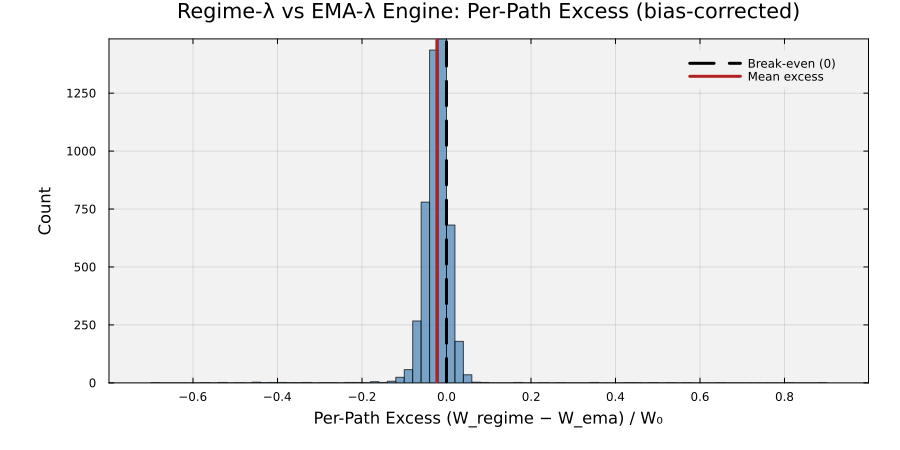

In [10]:
let
    excess = result_eng_regime.final_wealth .- result_eng_ema.final_wealth;

    p = histogram(excess ./ B₀, bins = 80, alpha = 0.7, color = :steelblue,
        xlabel = "Per-Path Excess (W_regime − W_ema) / W₀",
        ylabel = "Count", title = "Regime-λ vs EMA-λ Engine: Per-Path Excess (bias-corrected)",
        label = "", fontsize = 18, size = (900, 450));
    vline!(p, [0.0], lw = 3, ls = :dash, c = :black, label = "Break-even (0)");
    vline!(p, [mean(excess) / B₀], lw = 3, c = :firebrick, label = "Mean excess");
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright, 
        left_margin = 12Plots.mm, right_margin = 6Plots.mm,
        top_margin = 4Plots.mm, bottom_margin = 8Plots.mm);
    p
end

___
## Summary
This example replaced the EMA-crossover sentiment signal with a regime-aware signal built directly from the regime-switching jump model's state posteriors. We partitioned the generative model's 50 states by the sign of their emission mean, collapsed the forward-filter output into a scalar bear-probability signal, and ran the Cobb-Douglas rebalancing engine first on a single forward path and then across the multi-path stress scenario to compare distributional behavior against the baseline.

> __Key Takeaways:__
>
> * __Generative-model posteriors are a free sentiment signal:__ A generative model that simulates a price path also yields a posterior over the latent regime at every step, which is a no-cost sentiment input for any allocator that consumes the same path. Collapsing per-state posteriors into a scalar via the sign of each emission mean is a one-line construction that maps cleanly to a scalar risk-aversion knob.
> * __Moving-average crossovers are a strong baseline against posteriors:__ On scenarios drawn from a generative model, a moving-average crossover extracts most of the regime information the model encodes. Posteriors give a smaller incremental edge over a well-tuned technical signal than the theoretical setup suggests, so the choice between them is largely a frequency-of-update and lag question.
> * __Regime lambda closes the S1 to S2 loop:__ The Session 1 surrogate is no longer just a path generator; it is also the sentiment input the Session 2 engine consumes. Students see the generative model in two complementary roles, synthesizing the forward-test scenario and informing the live allocator's risk decisions on that scenario.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___